In [155]:
import pandas as pd 
import os 

In [156]:
ftir_path = "../Dataset/FTIR Spectroscopy/FTIR_Data.csv"

ftir = pd.read_csv(ftir_path)

ftir.head()

,Sample ID,399.47297,400.89966,402.32635,403.75304,405.17973,406.60642,408.03311,409.4598,410.88649,...,3986.16961,3987.5963,3989.02299,3990.44968,3991.87637,3993.30306,3994.72975,3996.15644,Target,Unnamed: 2524
0,T0S01,1.037915,1.036230,1.036401,1.037039,1.035914,1.033689,1.029641,1.034977,1.024125,...,1.000002,1.000065,0.999998,1.000020,1.000036,1.000097,0.999949,1.000004,0%,NaN
1,T0S02,1.037610,1.036221,1.036341,1.037780,1.035899,1.035044,1.033415,1.031860,1.030765,...,1.000049,1.000065,1.000075,0.999839,1.000004,0.999980,0.999951,0.999848,0%,NaN
2,T0S03,1.037114,1.036068,1.036403,1.035932,1.035938,1.033783,1.036381,1.030560,1.036050,...,1.000045,1.000048,0.999944,0.999934,1.000033,1.000024,1.000030,1.000127,0%,NaN
3,T0S04,1.036670,1.036074,1.036775,1.036964,1.036054,1.033322,1.035164,1.034887,1.034782,...,1.000024,1.000062,0.999979,1.000097,0.999996,1.000120,1.000000,1.000068,0%,NaN
4,T0S05,1.033297,1.036027,1.037310,1.037565,1.035871,1.033380,1.030104,1.041717,1.032694,...,1.000006,1.000031,1.000118,0.999999,0.999984,1.000027,1.000105,1.000139,0%,NaN


In [157]:
print("Shape: " , ftir.shape)
print("rows: " , ftir.shape[0])
print("columns: " , ftir.shape[1])

print("\nFirst 10 column names:")
print(ftir.columns[:10])

print("\nLast 10 column names:")
print(ftir.columns[-10:])


Shape:  (350, 2525)
rows:  350
columns:  2525

First 10 column names:
Index(['Sample ID', '399.47297', '400.89966', '402.32635', '403.75304',
       '405.17973', '406.60642', '408.03311', '409.4598', '410.88649'],
      dtype='str')

Last 10 column names:
Index(['3986.16961', '3987.5963', '3989.02299', '3990.44968', '3991.87637',
       '3993.30306', '3994.72975', '3996.15644', 'Target', 'Unnamed: 2524'],
      dtype='str')


In [158]:
print("Target values:")
print(ftir["Target"].unique())

print("\nTarget distribution:")
print(ftir["Target"].value_counts().sort_index())

print("\nFirst 10 Sample IDs and Targets:")
print(ftir[["Sample ID", "Target"]].head(10))

print("\nUnnamed column:")
print(ftir["Unnamed: 2524"].head(10))

print("\nMissing values:")
print(ftir[["Target", "Unnamed: 2524"]].isnull().sum())

print("Unnamed column unique values:")
print(ftir["Unnamed: 2524"].unique())

print("\nData types:")
print(ftir.dtypes.tail(5))

Target values:
<StringArray>
['0%', '1%', '2%', '3%', '5%', '7%', '9%']
Length: 7, dtype: str

Target distribution:
Target
0%    50
1%    50
2%    50
3%    50
5%    50
7%    50
9%    50
Name: count, dtype: int64

First 10 Sample IDs and Targets:
  Sample ID Target
0     T0S01     0%
1     T0S02     0%
2     T0S03     0%
3     T0S04     0%
4     T0S05     0%
5     T0S06     0%
6     T0S07     0%
7     T0S08     0%
8     T0S09     0%
9     T0S10     0%

Unnamed column:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: Unnamed: 2524, dtype: float64

Missing values:
Target             0
Unnamed: 2524    350
dtype: int64
Unnamed column unique values:
[nan]

Data types:
3993.30306       float64
3994.72975       float64
3996.15644       float64
Target               str
Unnamed: 2524    float64
dtype: object


In [159]:
ftir["Unnamed: 2524"].unique()
print(ftir["Unnamed: 2524"].unique())

[nan]


columns.str.match(r"^\d") :- here we are finding column s that start witha digit. In our case, the spectral columns start with a digit (wavenumber) and the other columns are metadata columns that do not start with a digit.

In [160]:
import matplotlib.pyplot as plt

spectral_columns = ftir.columns[
    ftir.columns.str.match(r"^\d")
]

print("Number of spectral columns:", len(spectral_columns))
print("First spectral column:", spectral_columns[0])
print("Last spectral column:", spectral_columns[-1])

Number of spectral columns: 2522
First spectral column: 399.47297
Last spectral column: 3996.15644


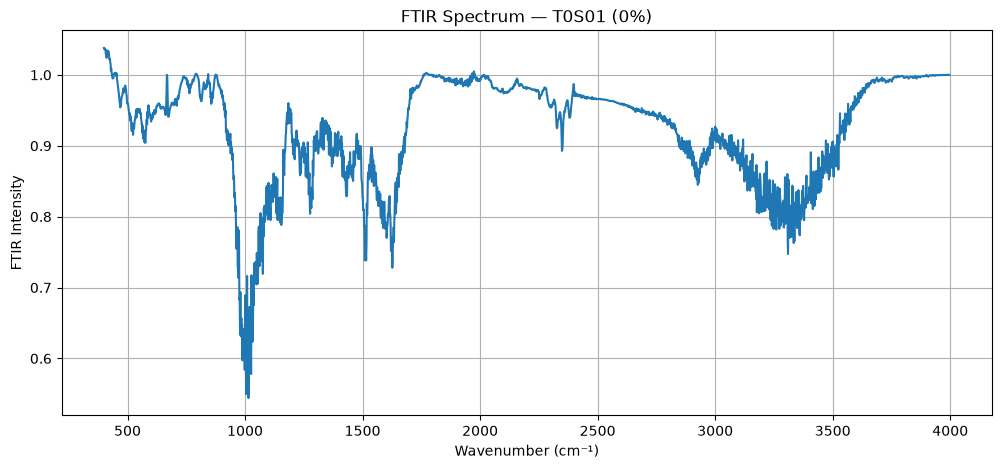

In [161]:
sample = ftir.iloc[0] # iloc :- give me the first roww 

x = spectral_columns.astype(float) # this is the x -axis :- wavenumber (cm⁻¹)
y = sample[spectral_columns].astype(float) # this is the y axis :- measurenment

plt.figure(figsize=(12, 5))

plt.plot(x, y)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("FTIR Intensity")
plt.title(f"FTIR Spectrum — {sample['Sample ID']} ({sample['Target']})")

plt.grid(True)
plt.show()

## key  insights:-

Around ~1000 cm⁻¹

There's a very strong drop:

~1000 cm⁻¹
     ↓
intensity falls substantially

This is a strong spectral feature.

Around ~1500–1700 cm⁻¹

There are several smaller peaks/valleys.

Around ~2800–3500 cm⁻¹

There's a broad region where the signal changes considerably, especially around ~3200–3400 cm⁻¹.

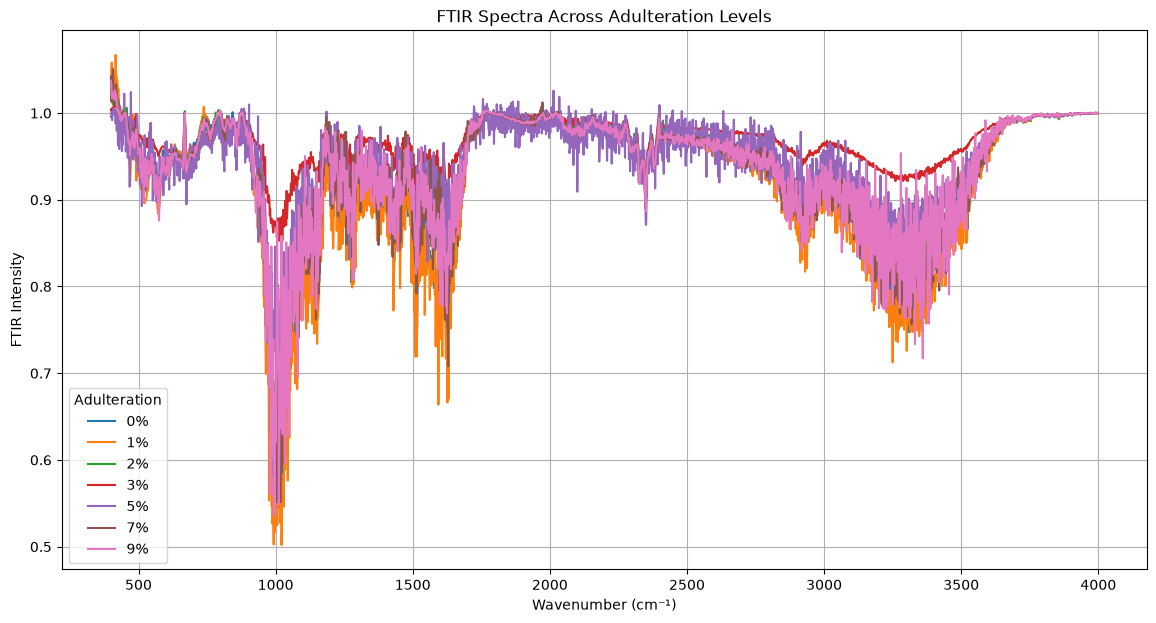

In [162]:
targets_to_plot = ["0%", "1%", "2%", "3%", "5%", "7%", "9%"]

plt.figure(figsize=(14, 7))

for target in targets_to_plot: #Go through each adulteration level one by one.
    sample = ftir[ftir["Target"] == target].iloc[0] #Give me only the samples belonging to that target.

    x = spectral_columns.astype(float)
    y = sample[spectral_columns].astype(float)

    plt.plot(x, y, label=target)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("FTIR Intensity")
plt.title("FTIR Spectra Across Adulteration Levels")

plt.legend(title="Adulteration")
plt.grid(True)

plt.show()

~400 → changes

~1000 → strong absorption region

~1200–1700 → many variations

~1800–2800 → relatively smoother

~3000–3500 → broad variation

~3700+ → curves converge again

This is a strong spectral feature.

Around ~1500–1700 cm⁻¹

There are several smaller peaks/valleys.

Around ~2800–3500 cm⁻¹

There's a broad region where the signal changes considerably, especially around ~3200–3400 cm⁻¹.

STEP 3 — Mean spectrum for each adulteration level

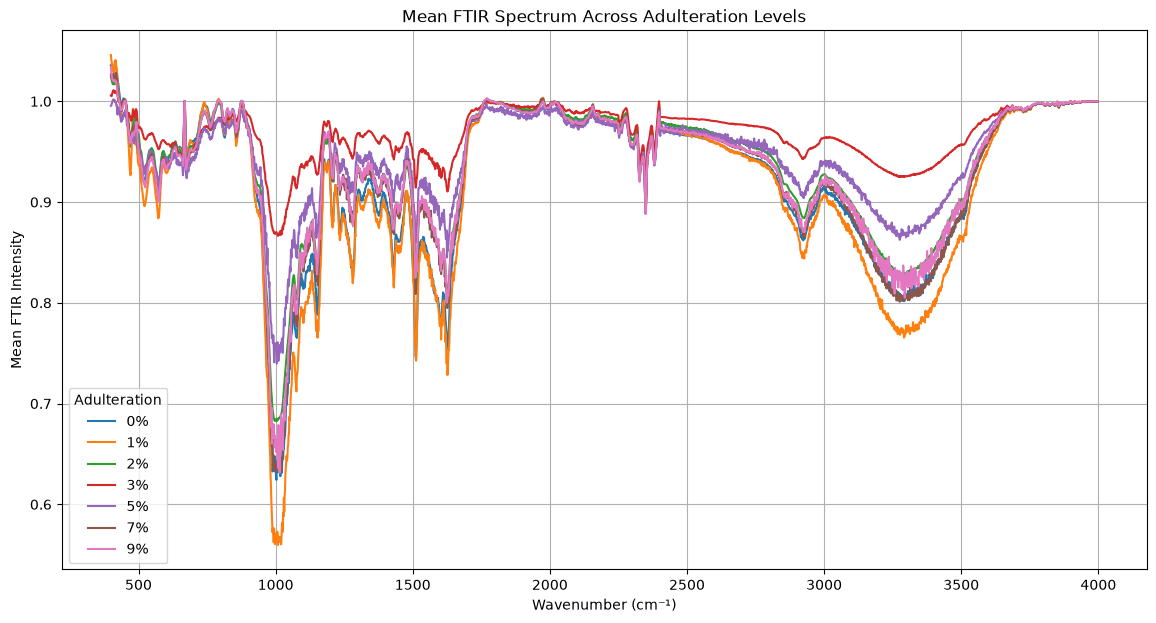

In [163]:
plt.figure(figsize=(14, 7))

x = spectral_columns.astype(float)

for target in targets_to_plot:

    class_data = ftir[ftir["Target"] == target]

    mean_spectrum = class_data[spectral_columns].astype(float).mean(axis=0) # So we get one representative spectrum for that class.

    plt.plot(x, mean_spectrum, label=target)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Mean FTIR Intensity")
plt.title("Mean FTIR Spectrum Across Adulteration Levels")

plt.legend(title="Adulteration")
plt.grid(True)

plt.show()

NOTE :- HERE Each curve is the average of 50 samples for that adulteration level.

some clear observations.:-

1. The classes still have similar overall shapes

That makes sense because every sample is based on turmeric.

So we see a common spectral fingerprint across all classes.

2. . Some regions show noticeable class differences

Especially around:

~900–1700 cm⁻¹
~2800–3500 cm⁻¹

For example, around ~3200–3400 cm⁻¹, the mean curves separate noticeably.

That means these regions may contain information useful to the ML model.

3. Very important: the relationship isn't simply monotonic:- 

Adulteration detection may depend on complex spectral patterns across many wavelengths rather than one simple peak.


STEP 4 — Check spectral data quality

In [164]:
# Select only the spectral measurements
spectral_data = ftir[spectral_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

# Check missing values
total_missing = spectral_data.isna().sum().sum()
columns_with_missing = spectral_data.isna().sum().gt(0).sum()
rows_with_missing = spectral_data.isna().any(axis=1).sum()

print("Total missing spectral values:", total_missing)
print("Spectral columns containing missing values:", columns_with_missing)
print("Samples containing missing spectral values:", rows_with_missing)

duplicate_ids = ftir["Sample ID"].duplicated().sum()
print("Duplicate Sample IDs:", duplicate_ids)

Total missing spectral values: 0
Spectral columns containing missing values: 0
Samples containing missing spectral values: 0
Duplicate Sample IDs: 0


## UNDERSTAND THE PATTERN OF THE SPECTRAL LINES 

In [165]:
print("First 10 IDs:")
print(ftir["Sample ID"].head(10).tolist())

print("\nLast 10 IDs:")
print(ftir["Sample ID"].tail(10).tolist())

print("\nFirst 10 targets:")
print(ftir["Target"].head(10).tolist())

print("\nLast 10 targets:")
print(ftir["Target"].tail(10).tolist())

First 10 IDs:
['T0S01', 'T0S02', 'T0S03', 'T0S04', 'T0S05', 'T0S06', 'T0S07', 'T0S08', 'T0S09', 'T0S10']

Last 10 IDs:
['T9S41', 'T9S42', 'T9S43', 'T9S44', 'T9S45', 'T9S46', 'T9S47', 'T9S48', 'T9S49', 'T9S50']

First 10 targets:
['0%', '0%', '0%', '0%', '0%', '0%', '0%', '0%', '0%', '0%']

Last 10 targets:
['9%', '9%', '9%', '9%', '9%', '9%', '9%', '9%', '9%', '9%']


In [166]:
# Extract the treatment prefix from Sample ID
ftir["ID_Prefix"] = ftir["Sample ID"].str.extract(r"^(T\d+)")

# Compare each ID prefix with its actual target
mapping_check = (
    ftir.groupby("ID_Prefix")["Target"]
    .unique()
)

prefix_counts = (
    ftir.groupby(["ID_Prefix", "Target"])
    .size()
    .reset_index(name="Count")
)

print(prefix_counts)
print(mapping_check)

  ID_Prefix Target  Count
0        T0     0%     50
1        T1     1%     50
2        T2     2%     50
3        T3     3%     50
4        T5     5%     50
5        T7     7%     50
6        T9     9%     50
ID_Prefix
T0    [0%]
T1    [1%]
T2    [2%]
T3    [3%]
T5    [5%]
T7    [7%]
T9    [9%]
Name: Target, dtype: object


C:\Users\Dell\AppData\Local\Temp\ipykernel_18408\1657554888.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ftir["ID_Prefix"] = ftir["Sample ID"].str.extract(r"^(T\d+)")


### now we do a color measurement audit:- 

In [167]:
color_path = "../Dataset/Color Measurement/Hunter_Lab_colorimeter.csv"

color = pd.read_csv(color_path)

color.head()

,Sample_ID,L*,a*,b*,360,370,380,390,400,410,...,700,710,720,730,740,750,760,770,780,Target
0,T0S01,63.47,23.05,45.54,8.90,8.91,8.73,9.07,9.17,9.21,...,66.34,67.67,68.75,69.85,70.93,71.88,72.66,73.49,74.20,0%
1,T0S02,63.39,23.10,45.68,8.84,8.87,8.74,8.92,9.05,9.10,...,66.36,67.64,68.75,69.83,70.94,71.88,72.72,73.53,74.20,0%
2,T0S03,63.02,23.17,45.09,8.90,8.92,8.66,8.89,9.05,9.10,...,65.80,67.13,68.20,69.29,70.40,71.37,72.17,72.88,73.59,0%
3,T0S04,63.08,23.20,45.44,8.80,8.81,8.61,8.83,8.96,9.00,...,66.00,67.34,68.45,69.51,70.62,71.56,72.38,73.22,73.93,0%
4,T0S05,62.97,23.23,45.22,8.86,8.88,8.66,8.85,8.98,9.02,...,65.93,67.30,68.38,69.44,70.55,71.54,72.38,73.20,73.97,0%


STEP 1 — Get the exact Color structure

In [168]:
print("Shape:", color.shape)

print("\nNumber of rows:", color.shape[0])
print("Number of columns:", color.shape[1])

print("\nAll column names:")
print(color.columns.tolist())

Shape: (350, 48)

Number of rows: 350
Number of columns: 48

All column names:
['Sample_ID', 'L*', 'a*', 'b*', '360', '370', '380', '390', '400', '410', '420', '430', '440', '450', '460', '470', '480', '490', '500', '510', '520', '530', '540', '550', '560', '570', '580', '590', '600', '610', '620', '630', '640', '650', '660', '670', '680', '690', '700', '710', '720', '730', '740', '750', '760', '770', '780', 'Target']


STEP 2 — Check the target distribution

In [169]:
print("Target values:")
print(color["Target"].unique())

print("\nTarget distribution:")
print(color["Target"].value_counts().sort_index())

Target values:
<StringArray>
['0%', '1%', '2%', '3%', '5%', '7%', '9%']
Length: 7, dtype: str

Target distribution:
Target
0%    50
1%    50
2%    50
3%    50
5%    50
7%    50
9%    50
Name: count, dtype: int64


STEP 3 — Check IDs

In [170]:
print("First 10 Sample IDs:")
print(color["Sample_ID"].head(10).tolist())

print("\nLast 10 Sample IDs:")
print(color["Sample_ID"].tail(10).tolist())

print("\nDuplicate Sample IDs:")
print(color["Sample_ID"].duplicated().sum())

First 10 Sample IDs:
['T0S01', 'T0S02', 'T0S03', 'T0S04', 'T0S05', 'T0S06', 'T0S07', 'T0S08', 'T0S09', 'T0S10']

Last 10 Sample IDs:
['T9S41', 'T9S42', 'T9S43', 'T9S44', 'T9S45', 'T9S46', 'T9S47', 'T9S48', 'T9S49', 'T9S50']

Duplicate Sample IDs:
0


In [171]:
ftir_ids = set(ftir["Sample ID"])
color_ids = set(color["Sample_ID"])

print("FTIR samples:", len(ftir_ids))
print("Color samples:", len(color_ids))

print("\nFTIR IDs missing from Color:")
print(ftir_ids - color_ids)

print("\nColor IDs missing from FTIR:")
print(color_ids - ftir_ids)

print("\nExact ID match:", ftir_ids == color_ids)

FTIR samples: 350
Color samples: 350

FTIR IDs missing from Color:
set()

Color IDs missing from FTIR:
set()

Exact ID match: True


In [172]:
color_features = color.drop(columns=["Sample_ID", "Target"])

color_numeric = color_features.apply(
    pd.to_numeric,
    errors="coerce"
)

print("Total missing color values:",
      color_numeric.isna().sum().sum())

print("Columns with missing values:",
      color_numeric.isna().sum().gt(0).sum())

print("Rows with missing values:",
      color_numeric.isna().any(axis=1).sum())

Total missing color values: 0
Columns with missing values: 0
Rows with missing values: 0


In [173]:
print(color.dtypes)

Sample_ID        str
L*           float64
a*           float64
b*           float64
360          float64
370          float64
380          float64
390          float64
400          float64
410          float64
420          float64
430          float64
440          float64
450          float64
460          float64
470          float64
480          float64
490          float64
500          float64
510          float64
520          float64
530          float64
540          float64
550          float64
560          float64
570          float64
580          float64
590          float64
600          float64
610          float64
620          float64
630          float64
640          float64
650          float64
660          float64
670          float64
680          float64
690          float64
700          float64
710          float64
720          float64
730          float64
740          float64
750          float64
760          float64
770          float64
780          float64
Target       

## now we move to the image partt 


In [174]:
import os

image_root = "../dataset/Image"

print("Image folders:")
print(os.listdir(image_root))

Image folders:
['0%', '1%', '2%', '3%', '5%', '7%', '9%', 'EfficientNetB0_Image_Features']


In [175]:
for folder in ["0%", "1%", "2%", "3%", "5%", "7%", "9%"]:
    
    folder_path = os.path.join(image_root, folder)
    
    files = os.listdir(folder_path)
    
    print(f"{folder}: {len(files)} files")
    print("  First 5:", files[:5])

0%: 50 files
  First 5: ['T0S01.JPG', 'T0S02.JPG', 'T0S03.JPG', 'T0S04.JPG', 'T0S05.JPG']
1%: 50 files
  First 5: ['T1S01.JPG', 'T1S02.JPG', 'T1S03.JPG', 'T1S04.JPG', 'T1S05.JPG']
2%: 50 files
  First 5: ['T2S01.JPG', 'T2S02.JPG', 'T2S03.JPG', 'T2S04.JPG', 'T2S05.JPG']
3%: 50 files
  First 5: ['T3S01.JPG', 'T3S02.JPG', 'T3S03.JPG', 'T3S04.JPG', 'T3S05.JPG']
5%: 50 files
  First 5: ['T5S01.JPG', 'T5S02.JPG', 'T5S03.JPG', 'T5S04.JPG', 'T5S05.JPG']
7%: 50 files
  First 5: ['T7S01.JPG', 'T7S02.JPG', 'T7S03.JPG', 'T7S04.JPG', 'T7S05.JPG']
9%: 50 files
  First 5: ['T9S01.JPG', 'T9S02.JPG', 'T9S03.JPG', 'T9S04.JPG', 'T9S05.JPG']


In [176]:
from PIL import Image

sample_image_path = os.path.join(
    image_root,
    "0%",
    "T0S01.JPG"
)

img = Image.open(sample_image_path)

print("Image format:", img.format)
print("Image size:", img.size)
print("Image mode:", img.mode)

Image format: JPEG
Image size: (3862, 3829)
Image mode: RGB


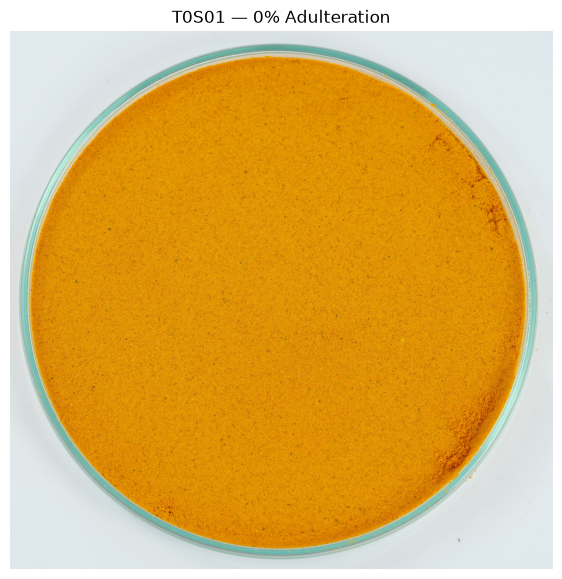

In [177]:
plt.figure(figsize=(7, 7))

plt.imshow(img)
plt.axis("off")
plt.title("T0S01 — 0% Adulteration")

plt.show()

In [178]:
from collections import Counter

image_sizes = []
image_modes = []

for folder in ["0%", "1%", "2%", "3%", "5%", "7%", "9%"]:
    folder_path = os.path.join(image_root, folder)

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        with Image.open(file_path) as im:
            image_sizes.append(im.size)
            image_modes.append(im.mode)

print("Total images checked:", len(image_sizes))

print("\nUnique image sizes:")
print(Counter(image_sizes))

print("\nUnique image modes:")
print(Counter(image_modes))

Total images checked: 350

Unique image sizes:
Counter({(3907, 3907): 4, (3816, 3816): 3, (3861, 3876): 2, (4000, 4000): 2, (3883, 3846): 2, (3985, 3938): 2, (3831, 3860): 2, (3970, 3922): 2, (3748, 3785): 2, (3922, 3922): 2, (3986, 3938): 2, (3862, 3846): 2, (3868, 3846): 2, (3853, 3846): 2, (3793, 3770): 2, (3907, 3877): 2, (3943, 3860): 2, (3862, 3829): 1, (3779, 3846): 1, (3934, 3877): 1, (3837, 3770): 1, (3713, 3741): 1, (3830, 3860): 1, (3922, 4000): 1, (3985, 3953): 1, (3836, 3891): 1, (3609, 3650): 1, (3876, 3861): 1, (3831, 3861): 1, (3932, 3953): 1, (3883, 3728): 1, (3993, 3953): 1, (3977, 3783): 1, (3956, 3877): 1, (3957, 3876): 1, (3901, 3938): 1, (3900, 3900): 1, (4001, 3969): 1, (3762, 3725): 1, (3849, 3815): 1, (4155, 4000): 1, (3918, 3907): 1, (3847, 3846): 1, (4031, 3907): 1, (3900, 3869): 1, (3865, 3907): 1, (3833, 3831): 1, (3837, 3862): 1, (3926, 3877): 1, (3829, 3862): 1, (3964, 3907): 1, (3985, 4000): 1, (3946, 4000): 1, (3938, 4000): 1, (3885, 3831): 1, (3855, 38

In [179]:
image_ids = []

for folder in ["0%", "1%", "2%", "3%", "5%", "7%", "9%"]:
    folder_path = os.path.join(image_root, folder)

    for filename in os.listdir(folder_path):
        # Remove the .JPG extension
        sample_id = os.path.splitext(filename)[0]
        image_ids.append(sample_id)

image_ids = set(image_ids)

print("Image samples:", len(image_ids))
print("FTIR samples:", len(ftir_ids))
print("Color samples:", len(color_ids))

print("\nImage IDs missing from FTIR:")
print(image_ids - ftir_ids)

print("\nFTIR IDs missing from Image:")
print(ftir_ids - image_ids)

print("\nImage ↔ FTIR exact match:", image_ids == ftir_ids)

print("\nImage ↔ Color exact match:", image_ids == color_ids)

Image samples: 350
FTIR samples: 350
Color samples: 350

Image IDs missing from FTIR:
set()

FTIR IDs missing from Image:
set()

Image ↔ FTIR exact match: True

Image ↔ Color exact match: True


EfficientNet-B0 Features

In [180]:
efficientnet_path = (
    "../Dataset/Image/"
    "EfficientNetB0_Image_Features/"
    "EfficientNetB0_Image_Features.csv"
)

efficientnet = pd.read_csv(efficientnet_path)

efficientnet.head()

,Sample_ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_1272,Feature_1273,Feature_1274,Feature_1275,Feature_1276,Feature_1277,Feature_1278,Feature_1279,Feature_1280,Target
0,T0S01,-0.149074,-0.047830,-0.024970,-0.090157,-0.026123,0.197063,-0.191883,-0.087269,0.039225,...,-0.128627,2.799380,-0.112083,-0.073458,1.008949,-0.090021,-0.098225,-0.194120,-0.163538,0
1,T0S02,-0.125764,-0.040440,-0.041863,-0.095619,0.055201,0.302645,-0.194103,-0.099726,0.073105,...,-0.121896,2.595050,-0.101397,-0.095209,0.953625,-0.083403,-0.056169,-0.167551,-0.128815,0
2,T0S03,-0.137168,-0.046979,-0.050521,-0.126286,0.008802,0.120511,-0.193411,-0.089287,-0.071056,...,-0.137743,2.022523,-0.127374,-0.106574,1.122557,-0.078075,-0.024927,-0.146901,-0.116668,0
3,T0S04,-0.148400,-0.042673,-0.073778,-0.114719,0.023353,0.346130,-0.191926,-0.086195,0.017622,...,-0.124894,2.585489,-0.072676,-0.076126,1.036155,-0.081636,-0.038049,-0.174885,-0.148465,0
4,T0S05,-0.140647,-0.045826,-0.028092,-0.110010,0.015048,0.284736,-0.196062,-0.084509,0.003395,...,-0.119905,2.885336,-0.045663,-0.068658,1.107461,-0.076154,-0.105997,-0.190261,-0.165307,0


In [181]:
print("Shape:", efficientnet.shape)

print("\nRows:", efficientnet.shape[0])
print("Columns:", efficientnet.shape[1])

print("\nFirst 10 columns:")
print(efficientnet.columns[:10].tolist())

print("\nLast 10 columns:")
print(efficientnet.columns[-10:].tolist())

Shape: (350, 1282)

Rows: 350
Columns: 1282

First 10 columns:
['Sample_ID', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9']

Last 10 columns:
['Feature_1272', 'Feature_1273', 'Feature_1274', 'Feature_1275', 'Feature_1276', 'Feature_1277', 'Feature_1278', 'Feature_1279', 'Feature_1280', 'Target']


In [182]:
print("Target column present:",
      "Target" in efficientnet.columns)

print("\nColumns containing 'target':")
print([
    col for col in efficientnet.columns
    if "target" in col.lower()
])

Target column present: True

Columns containing 'target':
['Target']


In [183]:
feature_columns = [
    col for col in efficientnet.columns
    if col != "Sample_ID"
]

print("Number of feature columns:", len(feature_columns))

print("\nFeature data types:")
print(efficientnet[feature_columns].dtypes.value_counts())

Number of feature columns: 1281

Feature data types:
float64    1280
int64         1
Name: count, dtype: int64


In [184]:
feature_data = efficientnet[feature_columns]

print("Total missing feature values:",
      feature_data.isna().sum().sum())

print("Columns with missing values:",
      feature_data.isna().sum().gt(0).sum())

print("Rows with missing values:",
      feature_data.isna().any(axis=1).sum())

Total missing feature values: 0
Columns with missing values: 0
Rows with missing values: 0


In [185]:
efficientnet_ids = set(efficientnet["Sample_ID"])

print("EfficientNet samples:", len(efficientnet_ids))
print("FTIR samples:", len(ftir_ids))
print("Color samples:", len(color_ids))
print("Raw image samples:", len(image_ids))

print("\nEfficientNet IDs missing from FTIR:")
print(efficientnet_ids - ftir_ids)

print("\nFTIR IDs missing from EfficientNet:")
print(ftir_ids - efficientnet_ids)

print("\nEfficientNet ↔ FTIR exact match:",
      efficientnet_ids == ftir_ids)

print("\nEfficientNet ↔ Color exact match:",
      efficientnet_ids == color_ids)

print("\nEfficientNet ↔ Raw Image exact match:",
      efficientnet_ids == image_ids)

EfficientNet samples: 350
FTIR samples: 350
Color samples: 350
Raw image samples: 350

EfficientNet IDs missing from FTIR:
set()

FTIR IDs missing from EfficientNet:
set()

EfficientNet ↔ FTIR exact match: True

EfficientNet ↔ Color exact match: True

EfficientNet ↔ Raw Image exact match: True
